In [1]:
import pandas as pd
import numpy as np

## Данные соревнования МТС: https://ods.ai/competitions/competition-recsys-21/data

In [3]:
#!pip install pandas numpy scikit-learn implicit torch tqdm

In [101]:
df = pd.read_csv("../../interactions.csv")
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [102]:
df["last_watch_dt"] = pd.to_datetime(df["last_watch_dt"]) - pd.to_datetime(df["last_watch_dt"]).min()
df["last_watch_dt"] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
2901623,891490,9465,111,27309,100.0
1807081,846557,9996,72,60132,100.0
3763755,253548,15297,138,87,0.0
13805,159855,14266,128,2702,20.0
5396734,971142,7713,24,7670,100.0


In [103]:
df.shape, df['user_id'].nunique(), df['item_id'].nunique()

((5476251, 5), 962179, 15706)

<Axes: >

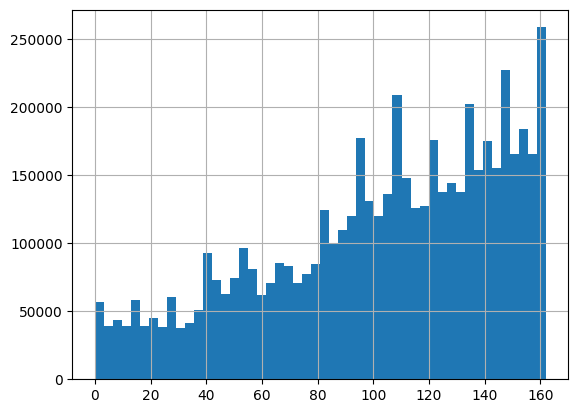

In [104]:
df['last_watch_dt'].hist(bins=50)

In [105]:
max_watch_dt = df['last_watch_dt'].max()
max_watch_dt

162

#### Разобьем датасет на трейн и тест. В тест отправим все события за последние 30 дней, В трейн все остальное. Посчитаем число уникальных юзеров в трейне и тесте, и юзеров, которые есть и там и там. Затем оставим в тесте только тех юзеров/айтемы, которые есть в трейне

In [106]:
# your code here
train_df = df.loc[df.last_watch_dt < 162-30].copy()
test_df = df.loc[df.last_watch_dt >= 162-30].copy()

assert train_df.shape[0] == 3740952
assert test_df.shape[0] == 1735299 

In [107]:
# your code here

old_shape = test_df.shape[0]

test_df = test_df.loc[test_df.user_id.isin(train_df.user_id.unique())].copy()
test_df = test_df.loc[test_df.item_id.isin(train_df.item_id.unique())].copy()

assert test_df.shape[0] == 851974
assert test_df['user_id'].nunique() == 186701
assert test_df['item_id'].nunique() == 8867


print(f"Размер тестовой выборки после фильтрации: {test_df.shape[0]} (было удалено {old_shape - test_df.shape[0]} строк или {100 * (old_shape - test_df.shape[0]) / old_shape:.2f}%)")
print(f"Число уникальных пользователей в тестовой выборке: {test_df.user_id.nunique()}")

Размер тестовой выборки после фильтрации: 851974 (было удалено 883325 строк или 50.90%)
Число уникальных пользователей в тестовой выборке: 186701


#### Насэмплируем 50_000 юзеров которые есть и в трейне и в тесте и ограничим тестовую и трейновую выборку только этими пользователями

In [108]:
np.random.seed(42)
train_users = train_df['user_id'].unique()
test_users = test_df.user_id.unique()
n_users = 50_000

intersection = np.intersect1d(train_users, test_users)

sampled_users = np.random.choice(intersection, n_users, replace=False)

train_df = train_df[train_df['user_id'].isin(sampled_users)]
test_df = test_df[test_df['user_id'].isin(sampled_users)]

assert train_df['last_watch_dt'].max() < test_df['last_watch_dt'].min()
assert train_df['user_id'].nunique() == n_users
assert test_df['user_id'].nunique() == n_users

In [109]:
test_df['user_id'].nunique()

50000

In [110]:
train_items = train_df['item_id'].unique()
test_df = test_df[test_df['item_id'].isin(train_items)].copy()

In [111]:
print(train_df['user_id'].nunique(), train_df['item_id'].nunique())
print(test_df['user_id'].nunique(), test_df['item_id'].nunique())
print(train_df.shape, test_df.shape)

50000 9743
49959 6159
(481529, 5) (227262, 5)


In [112]:
def ndcg_metric(gt_items, predicted):
    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(
        np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)), dtype=np.float64
    )


def recall_metric(gt_items, predicted):

    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / n_gt


def evaluate_recommender(df, model_preds, gt_col="test_interactions", topn=10):
    metric_values = []

    for idx, row in df.iterrows():
        gt_items = row[gt_col]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]), recall_metric(gt_items, row[model_preds])))

    return {"ndcg": np.mean([x[0] for x in metric_values]), "recall": np.mean([x[1] for x in metric_values])}

In [113]:
test_df_grouped = test_df.groupby('user_id').apply(lambda x: list(x['item_id'])).reset_index(name='test_interactions')
test_df_grouped.head()

,user_id,test_interactions
0,3,"[12192, 9728, 16406, 15719, 10440, 3475, 2025,..."
1,53,"[1445, 4151, 12250, 15629, 3734, 16426, 15810,..."
2,98,"[4689, 512, 5051]"
3,106,"[14619, 12908, 10544, 13335, 6267, 13463, 5411..."
4,155,"[8101, 5077, 281, 9006]"


### ALS

Итак, поставлена задача построения модели со скрытыми переменными (latent factor model) для коллаборативной фильтрации:

$$\sum_{u,i} (r_{ui} - \langle p_u, q_i \rangle)^2 \to \min_{P,Q}. $$

Напомним, что суммирование ведется по всем парам $(u, i),$ для которых известен рейтинг $r_{ui}$ (и только по ним), а $p_u, q_i$ – латентные представления пользователя $u$ и товара $i$ из соответствующих матрицы $P, Q$.

Подход ALS (Alternating Least Squares) решает задачу, попеременно фиксируя матрицы $P$ и $Q$, — оказывается, что, зафиксировав одну из матриц, можно выписать аналитическое решение задачи для другой.

$$\nabla_{p_u} \bigg[ \sum_{u,i} (r_{ui} - \langle p_u, q_i \rangle)^2 \bigg] = \sum_{i} 2(r_{ui} - \langle p_u, q_i \rangle)q_i = 0$$

Воспользовавшись тем, что $a^Tbc = cb^Ta$, получим
$$\sum_{i} r_{ui}q_i - \sum_i q_i q_i^T p_u = 0.$$
Тогда окончательно каждый столбец матрицы $P$ можно найти по формуле
$$p_u = \bigg( \sum_i q_i q_i^T\bigg)^{-1}\sum_ir_{ui}q_i \;\; \forall u,$$
аналогично для столбцов матрицы $Q$
$$q_i = \bigg( \sum_u p_u p_u^T\bigg)^{-1}\sum_ur_{ui}p_u \;\; \forall i.$$

Таким образом мы можем решать оптимизационную задачу, поочередно фиксируя одну из матриц $P$ или $Q$ и проводя оптимизацию по второй.

**Оригинальная статья (для explicit feedback):**

Bell, R.M. and Koren, Y., 2007, October. Scalable collaborative filtering with jointly derived neighborhood interpolation weights. In Seventh IEEE international conference on data mining (ICDM 2007) (pp. 43-52). IEEE.


### iALS


**Статья для implicit данных:**


Implicit feedback ALS:
* Hu, Y., Koren, Y. and Volinsky, C., 2008, December. Collaborative filtering for implicit feedback datasets. In 2008 Eighth IEEE international conference on data mining (pp. 263-272). Ieee. http://yifanhu.net/PUB/cf.pdf

**Особенности:**

1. Нет explicit данных (явных позитивных и отрицательных оценок). <br>
2. Много шума в данных.  <br>
3. Используются свои функции и метрики для оценки implicit feedback. Если в explicit $r_ui$ - это оценки предпочтений пользователя, то в implicit - это степень уверенности. <br>


| Критерий | ALS  |  iALS | 
|---|---|---|
| Тип данных | Этот подход используется, когда у вас есть явные рейтинги или оценки, предоставленные пользователями для различных предметов. Например, пользователи могут оценивать фильмы по шкале от 1 до 5. |  Этот подход используется, когда у вас есть неявные сигналы взаимодействия между пользователями и предметами, такие как клики, просмотры, покупки или временные интервалы между действиями. |  
|
|Цель | Модель стремится точно предсказать явные рейтинги или оценки, которые пользователи могли бы дать предметам. | Модель стремится моделировать уровень уверенности или важности взаимодействия между пользователем и предметом, но не предсказывает явные рейтинги.|  
|
|Функции потерь| Обычно использует функцию потерь, такую как среднеквадратичная ошибка (MSE), для минимизации разницы между предсказанными и фактическими оценками. | Использует функцию потерь, которая учитывает уверенность в неявных взаимодействиях и стремится увеличить уверенность для более важных взаимодействий.| 
|
|Взвешивание| Не уделяет внимания взаимодействиям, которые не были явно оценены пользователями. Исключает информацию о неявных действиях. | Дополнительная параметризация. Учитывает все неявные действия, но с учетом их уверенности или веса, что позволяет модели учесть важность различных видов взаимодействий| 
|

Библиотека implicit: https://benfred.github.io/implicit/

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm


class NaiveALS:
    def __init__(self, n_iters, n_factors, reg=0.1, alpha=40.0):
        self.n_iters = n_iters
        self.n_factors = n_factors
        self.reg = reg
        self.alpha = alpha

    def fit(self, train: pd.DataFrame):
        n_users = train["user_id"].nunique()
        n_items = train["item_id"].nunique()

        self.user_encoder = LabelEncoder()
        self.item_encoder = LabelEncoder()

        u = self.user_encoder.fit_transform(train["user_id"].values)
        i = self.item_encoder.fit_transform(train["item_id"].values)

        # implicit feedback matrix
        R = np.zeros((n_users, n_items), dtype=np.float32)
        R[u, i] = 1.0
        self.R = R

        self.P = np.random.normal(scale=0.1, size=(n_users, self.n_factors))
        self.Q = np.random.normal(scale=0.1, size=(n_items, self.n_factors))

        for _ in tqdm(range(self.n_iters)):
            self.P = self._als_step(R, self.P, self.Q)
            self.Q = self._als_step(R.T, self.Q, self.P)

    def _als_step(self, R, X, Y):
        """
        R: (n_entities, n_other)
        X: factors to solve
        Y: fixed factors
        """
        n_entities = R.shape[0]
        k = Y.shape[1]
        YtY = Y.T @ Y
        I = np.eye(k)

        X_new = np.zeros_like(X)

        for u in tqdm(range(n_entities)):
            r_u = R[u]
            idx = r_u > 0
            Y_u = Y[idx]                  # (n_pos, k)

            A =  YtY + (self.alpha - 1.0) * (Y_u.T @ Y_u) + self.reg * I)
            b = (1.0 + self.alpha) * Y_u.sum(axis=0)

            X_new[u] = np.linalg.solve(A, b)

        return X_new

    def predict(self):
        return self.P @ self.Q.T

    def get_top_k_predicts(self, k: int):
        scores = self.predict()
        scores[self.R > 0] = -np.inf

        topk = np.argsort(-scores, axis=1)[:, :k]

        user_ids = self.user_encoder.inverse_transform(
            np.arange(topk.shape[0])
        )
        item_ids = self.item_encoder.inverse_transform(
            topk.ravel()
        ).reshape(topk.shape)

        return pd.DataFrame({
            "user_id": user_ids,
            "predict": item_ids.tolist()
        })


In [117]:
naive_als = NaiveALS(n_iters=10, n_factors=16, reg=0.01, alpha=1)
naive_als.fit(train_df)

100%|██████████| 10/10 [01:03<00:00,  6.39s/it]


In [118]:
preds = naive_als.get_top_k_predicts(k=50)
test_df_grouped["als_recs_naive"] = preds['predict']
evaluate_recommender(test_df_grouped, model_preds="als_recs_naive")

{'ndcg': 0.20130794812354372, 'recall': 0.11683661883702154}

In [119]:
from typing import List

from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking

from sklearn.metrics import mean_squared_error


class ImplicitModel:
    def __init__(self, model):
        self.model = model
        self.trained = False

    def fit(self, train_df: pd.DataFrame):
        self.item_encoder = LabelEncoder()
        self.user_encoder = LabelEncoder()
        self.item_encoder.fit(train_df.item_id)
        self.user_encoder.fit(train_df.user_id)

        self.train_ratings = self.encode_table(train_df, ["user_id", "item_id"])
        self.model.fit(self.train_ratings)
        self.trained = True

    def predict(self, test_df: pd.DataFrame, top_k: int = 100):
        if not self.trained:
            raise ValueError("Model is not fitted. Please, fit the model first")
        users_to_predict = test_df.user_id
        encoded_users = self.user_encoder.transform(users_to_predict)
        user_recs = self.model.recommend(
            encoded_users, self.train_ratings[encoded_users], N=top_k, filter_already_liked_items=False
        )[0]
        recs = [self.item_encoder.inverse_transform(x) for x in user_recs]
        return recs

    def encode_table(self, df: pd.DataFrame, axis_names: List[str]) -> np.ndarray:
        user_ids = self.user_encoder.transform(df[axis_names[0]])
        item_ids = self.item_encoder.transform(df[axis_names[1]])

        matrix_shape = len(self.user_encoder.classes_), len(self.item_encoder.classes_)

        sparse = csr_matrix((np.ones(len(user_ids)), (user_ids, item_ids)), shape=matrix_shape, dtype=np.float32)

        return sparse

In [120]:
als = AlternatingLeastSquares(iterations=10, factors=16, regularization=0.01, calculate_training_loss=True)
als_recommender = ImplicitModel(als)
als_recommender.fit(train_df)

100%|██████████| 10/10 [00:00<00:00, 16.97it/s, loss=0.000772]


In [121]:
preds = als_recommender.predict(test_df_grouped, top_k=50)
test_df_grouped["als_recs"] = preds
evaluate_recommender(test_df_grouped, model_preds="als_recs")

{'ndcg': 0.30911639916946637, 'recall': 0.19601808222753728}

## Neural Collaborative Filtering

![Neumf](neumf.png)

## Neural Matrix Factorization (NeuMF)

Neural Matrix Factorization (NeuMF) — это гибридная модель коллаборативной фильтрации, объединяющая **Generalized Matrix Factorization (GMF)** и **Multi-Layer Perceptron (MLP)** для моделирования взаимодействий пользователей и объектов. Модель была предложена в работе *He et al., “Neural Collaborative Filtering”, WWW 2017* и ориентирована на сценарии **implicit feedback**.

---

## Обозначения

- $u \in \{1, \dots, |\mathcal{U}|\}$ — пользователь  
- $i \in \{1, \dots, |\mathcal{I}|\}$ — объект  
- $y_{ui} \in \{0,1\}$ — наблюдаемый implicit feedback  
- $\hat{y}_{ui} \in \mathbb{R}$ — предсказанный скор  
- $k$ — размерность латентных эмбеддингов  

---

## Generalized Matrix Factorization (GMF)

Пользователь и объект отображаются в латентное пространство:

$$
\mathbf{p}_u \in \mathbb{R}^k, \quad
\mathbf{q}_i \in \mathbb{R}^k
$$

Взаимодействие моделируется поэлементным произведением:

$$
\phi^{\text{GMF}}(u, i) = \mathbf{p}_u \odot \mathbf{q}_i
$$

В отличие от классической матричной факторизации, здесь не используется скалярное произведение, что позволяет модели быть более гибкой.

---

## Multi-Layer Perceptron (MLP)

Для MLP используются отдельные эмбеддинги:

$$
\mathbf{p}'_u \in \mathbb{R}^k, \quad
\mathbf{q}'_i \in \mathbb{R}^k
$$

Вход в нейросеть формируется конкатенацией:

$$
\mathbf{z}_0 =
\begin{bmatrix}
\mathbf{p}'_u \\
\mathbf{q}'_i
\end{bmatrix}
\in \mathbb{R}^{2k}
$$

Далее применяется $L$-слойный перцептрон:

$$
\mathbf{z}_\ell =
\sigma_\ell(\mathbf{W}_\ell \mathbf{z}_{\ell-1} + \mathbf{b}_\ell),
\quad \ell = 1, \dots, L
$$

где $\sigma_\ell(\cdot)$ — нелинейная функция активации (обычно ReLU).

Итоговое представление MLP:

$$
\phi^{\text{MLP}}(u, i) = \mathbf{z}_L
$$

---

## NeuMF: объединение GMF и MLP

Финальное представление получается конкатенацией GMF и MLP частей:

$$
\phi^{\text{NeuMF}}(u, i) =
\begin{bmatrix}
\phi^{\text{GMF}}(u, i) \\
\phi^{\text{MLP}}(u, i)
\end{bmatrix}
$$

Предсказанный скор вычисляется линейным преобразованием:

$$
\hat{y}_{ui} =
\mathbf{h}^\top \phi^{\text{NeuMF}}(u, i) + b
$$

где $\mathbf{h}$ и $b$ — обучаемые параметры модели.

---

## Функция потерь

Для implicit feedback обычно используется логистическая функция потерь:

$$
\mathcal{L} =
- \sum_{(u,i)}
\left[
y_{ui} \log \sigma(\hat{y}_{ui})
+
(1 - y_{ui}) \log \left(1 - \sigma(\hat{y}_{ui})\right)
\right]
$$

где $\sigma(\cdot)$ — сигмоида.

Альтернативно может использоваться pairwise-loss, например Bayesian Personalized Ranking (BPR):

$$
\mathcal{L}_{\text{BPR}} =
- \sum_{(u,i,j)}
\log \sigma(\hat{y}_{ui} - \hat{y}_{uj})
$$

---


Теперь надо реализовать такую модель на практике

In [143]:
user_encoder = LabelEncoder().fit(train_df["user_id"])
item_encoder = LabelEncoder().fit(train_df["item_id"])

In [144]:
import torch
import torch.nn as nn

In [145]:
train_encoded_users = torch.Tensor(user_encoder.transform(train_df["user_id"].values)).long()
train_encoded_items = torch.Tensor(item_encoder.transform(train_df["item_id"].values)).long()

In [146]:
user_encoder = LabelEncoder().fit(train_df["user_id"])
item_encoder = LabelEncoder().fit(train_df["item_id"])

In [148]:
def transform(x):
    encoded = item_encoder.transform(x)
    return encoded.tolist()

user_interactions = train_df.groupby(["user_id"]).agg({"item_id": transform})
user_interactions

,item_id
user_id,
3,"[2200, 1548]"
53,"[914, 9506, 8183, 960, 4463, 9057, 3904, 6191,..."
98,"[2672, 74, 1407, 977, 1210, 4889, 2932, 2819, ..."
106,"[1852, 5577, 164, 2803, 4024, 2112, 1487, 9537..."
155,"[8209, 215, 2791, 5413]"
...,...
1097470,"[5401, 2662, 8734, 1131, 4857, 9353, 8522, 518..."
1097474,"[2004, 8405]"
1097479,"[5413, 2200, 2819, 6331, 2393]"


In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class NCF(nn.Module):
    def __init__(
        self,
        n_users: int,
        m_items: int,
        n_factors: int,
        hidden_dim: int,
    ) -> None:
        super().__init__()

        self.m_items = m_items

        # Embeddings for GMF
        self.user_emb_gmf = nn.Embedding(n_users, n_factors)
        self.item_emb_gmf = nn.Embedding(m_items, n_factors)

        # Embeddings for MLP
        self.user_emb_mlp = nn.Embedding(n_users, n_factors)
        self.item_emb_mlp = nn.Embedding(m_items, n_factors)

        # MLP tower
        self.mlp = nn.Sequential(
            nn.Linear(2 * n_factors, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )

        # Final prediction layer
        self.out = nn.Linear(
            n_factors + hidden_dim // 2, 1
        )

        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.user_emb_gmf,
            self.item_emb_gmf,
            self.user_emb_mlp,
            self.item_emb_mlp,
        ]:
            nn.init.normal_(emb.weight, std=0.01)

        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

        nn.init.xavier_uniform_(self.out.weight)

    def forward(self, item: torch.Tensor, user: torch.Tensor) -> torch.Tensor:
        """
        item, user: LongTensor of shape (batch,)
        """

        # --- GMF part ---
        u_gmf = self.user_emb_gmf(user)      # (B, k)
        i_gmf = self.item_emb_gmf(item)      # (B, k)
        gmf = u_gmf * i_gmf                  # element-wise product

        # --- MLP part ---
        u_mlp = self.user_emb_mlp(user)      # (B, k)
        i_mlp = self.item_emb_mlp(item)      # (B, k)
        mlp_input = torch.cat([u_mlp, i_mlp], dim=-1)
        mlp_out = self.mlp(mlp_input)        # (B, hidden//2)

        # --- Fusion ---
        x = torch.cat([gmf, mlp_out], dim=-1)
        prediction = self.out(x).squeeze(-1)  # (B,)

        return prediction


In [153]:
ncf_model = NCF(n_users=len(user_encoder.classes_), m_items=len(item_encoder.classes_), n_factors=16, hidden_dim=64)
ncf_model

NCF(
  (user_emb_gmf): Embedding(50000, 16)
  (item_emb_gmf): Embedding(9743, 16)
  (user_emb_mlp): Embedding(50000, 16)
  (item_emb_mlp): Embedding(9743, 16)
  (mlp): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (out): Linear(in_features=48, out_features=1, bias=True)
)

In [158]:
from collections import deque
import numpy as np
from tqdm import tqdm

optimizer = torch.optim.Adam(ncf_model.parameters(), lr=1e-4)
loss_fn = nn.BCEWithLogitsLoss()

all_items = set(range(ncf_model.m_items))

# окно для скользящего среднего
window_size = 100
loss_window = deque(maxlen=window_size)

pbar = tqdm(
    zip(train_encoded_users, train_encoded_items),
    total=len(train_encoded_users),
)

for user, item in pbar:
    optimizer.zero_grad()

    # negative sampling
    seen_items = set(
        user_interactions.loc[user_encoder.inverse_transform([user.item()])]
    )
    unseen_items = list(all_items - seen_items)
    neg_item = torch.tensor(
        np.random.choice(unseen_items),
        dtype=torch.long
    )

    # predictions
    pos_prediction = ncf_model(
        item.unsqueeze(0),
        user.unsqueeze(0)
    )
    neg_prediction = ncf_model(
        neg_item.unsqueeze(0),
        user.unsqueeze(0)
    )

    # targets
    pos_target = torch.ones_like(pos_prediction)
    neg_target = torch.zeros_like(neg_prediction)

    # loss
    cur_loss = (
        loss_fn(pos_prediction, pos_target)
        + loss_fn(neg_prediction, neg_target)
    )

    cur_loss.backward()
    optimizer.step()

    # update loss window
    loss_window.append(cur_loss.item())
    avg_loss = np.mean(loss_window)

    # update tqdm bar
    pbar.set_postfix(
        loss=f"{avg_loss:.4f}"
    )


  6%|▌         | 28040/481529 [02:48<45:23, 166.53it/s, loss=0.7436]


KeyboardInterrupt: 

#### Реализовать инференс модели и подсчет метрик

В качестве доп. задания вам предлагается реализовать самостоятельно расчет метрик. Для этого вам по факту надо посчитать рекомендации для каждого юзера и аналогично оценить их по тестовой выборке